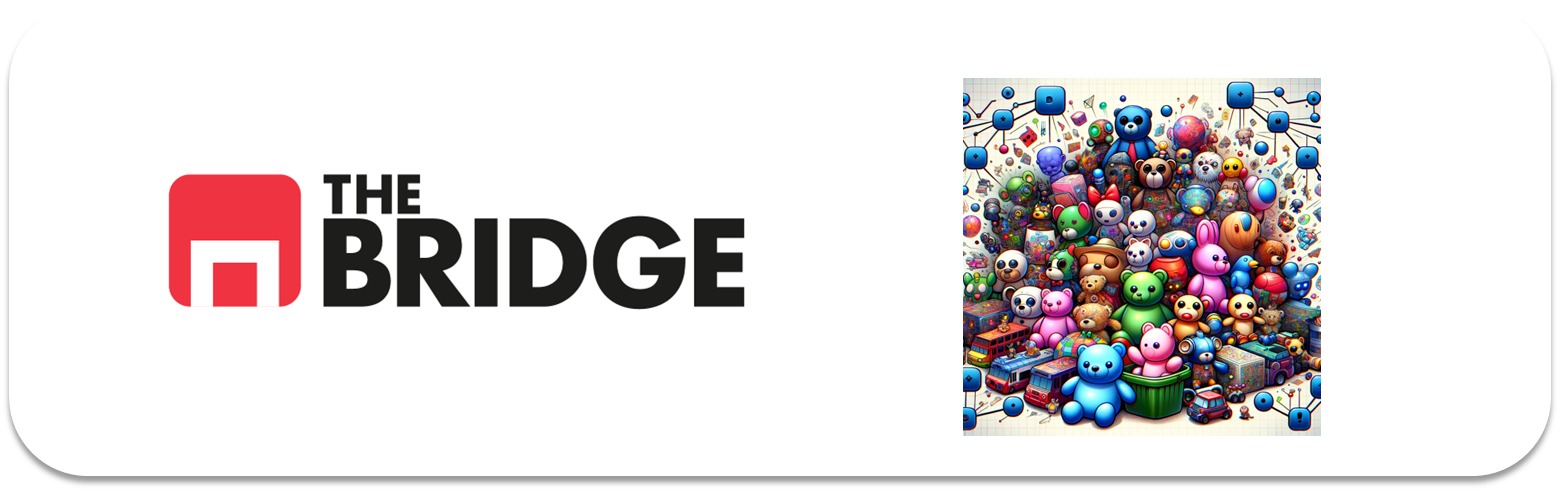

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
import scipy.cluster.hierarchy as shc

from bootcampviztools import grafico_dispersion_con_correlacion, plot_combined_graphs

np.random.seed(42)
%matplotlib inline


### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


### 1. Cargar datos y visualizar

In [ ]:
df = pd.read_csv("./data/empowering_drinks.csv", sep="|")
print(df.shape)
df.head()


(153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Azúcares,153.0,0.019231,1.026182,-2.434235,-0.816038,0.061000,0.876275,2.259772
Vitamínas del grupo B,153.0,0.037273,0.995984,-3.679162,-0.499016,-0.023821,0.707247,3.156325
Cafeína,153.0,0.041057,1.040928,-1.695971,-1.043392,0.211566,0.894264,3.062832
Ácido Cítrico,153.0,0.080022,1.009450,-1.493188,-0.738463,-0.165254,0.917474,2.971473
Taurina,153.0,-0.044088,0.934399,-1.634288,-0.799428,-0.154899,0.493956,2.431870


Ya de entrada vemos algo importante: no hay nulos, no hay duplicados (lo comprobamos abajo) y, sobre todo, **las 5 features ya vienen escaladas** (media ≈ 0, desviación típica ≈ 1 en todas las columnas). Es decir, los químicos ya nos entregan los datos estandarizados, así que nos ahorramos el paso de escalado manual — algo fundamental en clustering, ya que tanto DBSCAN como el clustering jerárquico se basan en distancias y son muy sensibles a que las variables estén en escalas distintas.

In [ ]:
print("Nulos por columna:\n", df.isna().sum())
print("\nFilas duplicadas:", df.duplicated().sum())


Nulos por columna:
 Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64

Filas duplicadas: 0


### 2. MiniEDA: selección de features

Visualizamos las variables dos a dos con un `pairplot` para ver si a simple vista ya se aprecian agrupaciones.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

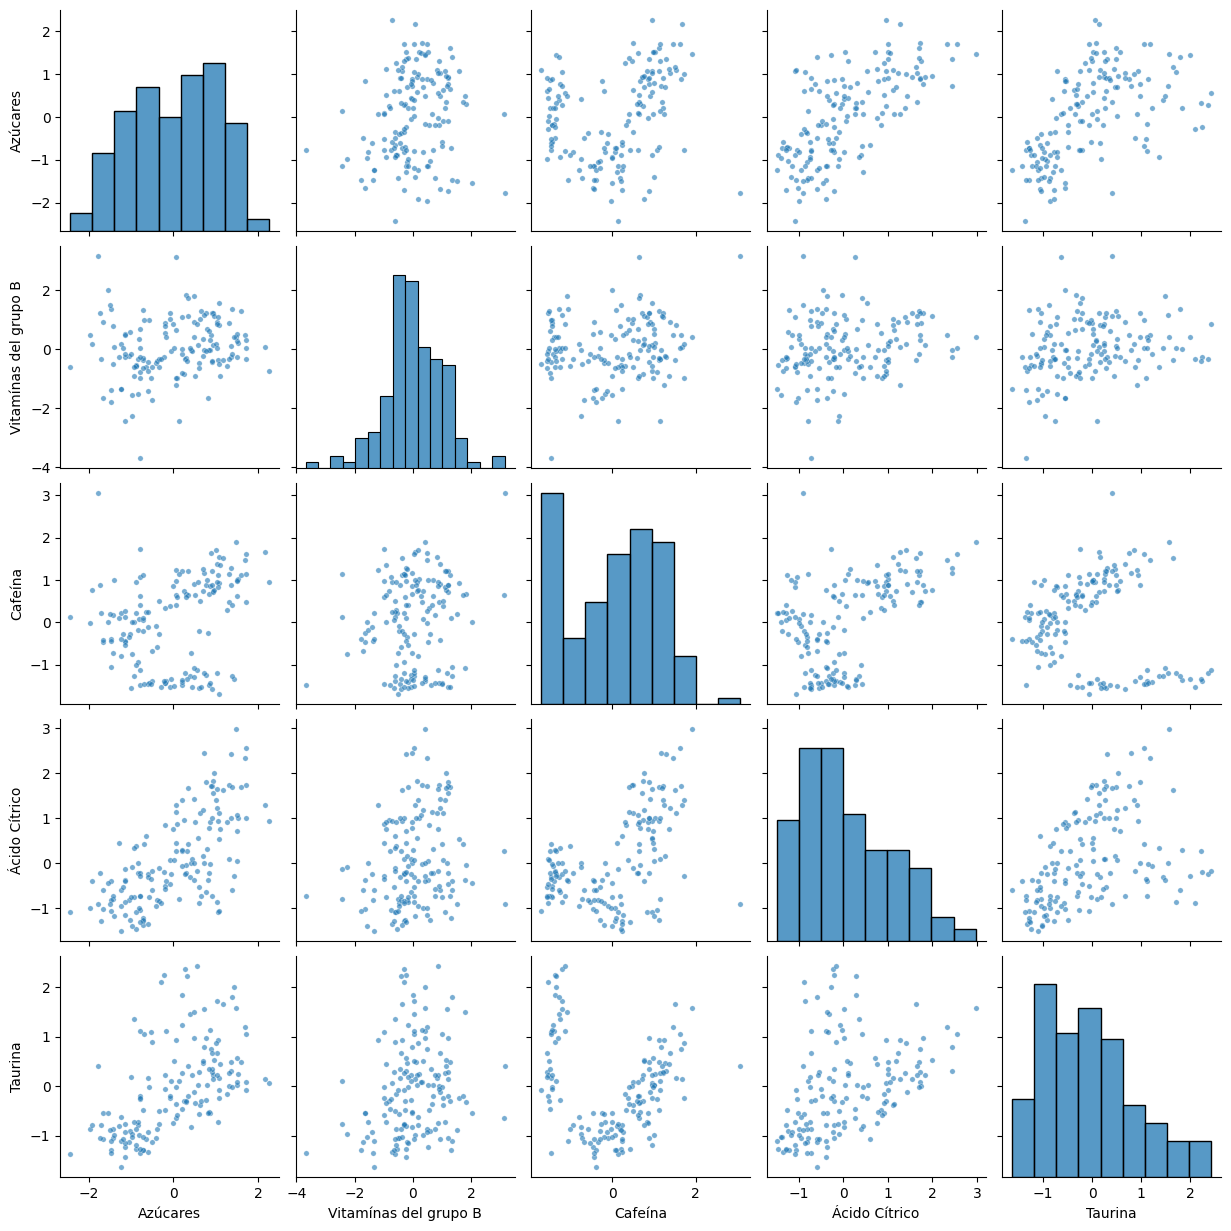

In [ ]:
sns.pairplot(df, plot_kws={"s": 15, "alpha": 0.6})
plt.show()


Se aprecian bastante bien un par de cosas:

* **Cafeína** es la variable que más claramente separa el dataset en (al menos) dos grandes grupos: su histograma es bimodal y, cruzada con **Ácido Cítrico** o con **Taurina**, se ven dos nubes de puntos bastante diferenciadas.
* **Azúcares**, **Ácido Cítrico** y **Taurina** están bastante correlacionadas entre sí (lo confirmamos con la matriz de correlación) y parecen aportar información parecida/redundante.
* **Vitamínas del grupo B** es la variable más "ruidosa": no muestra separación clara con ninguna otra, su nube de puntos es bastante homogénea en todos los cruces.

Vamos a confirmarlo con la matriz de correlación y con un par de scatter plots con correlación explícita usando las herramientas de `bootcampviztools`:

In [ ]:
df.corr()


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
Azúcares,1.000000,0.174354,0.258166,0.672969,0.553245
Vitamínas del grupo B,0.174354,1.000000,0.155276,0.208444,0.215869
Cafeína,0.258166,0.155276,1.000000,0.497329,-0.124157
Ácido Cítrico,0.672969,0.208444,0.497329,1.000000,0.408325
Taurina,0.553245,0.215869,-0.124157,0.408325,1.000000


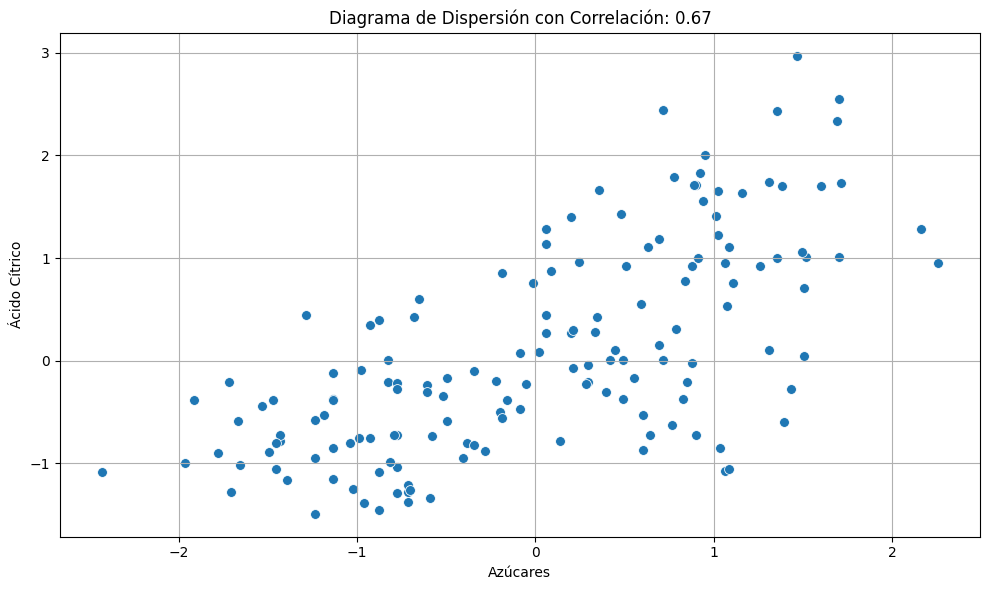

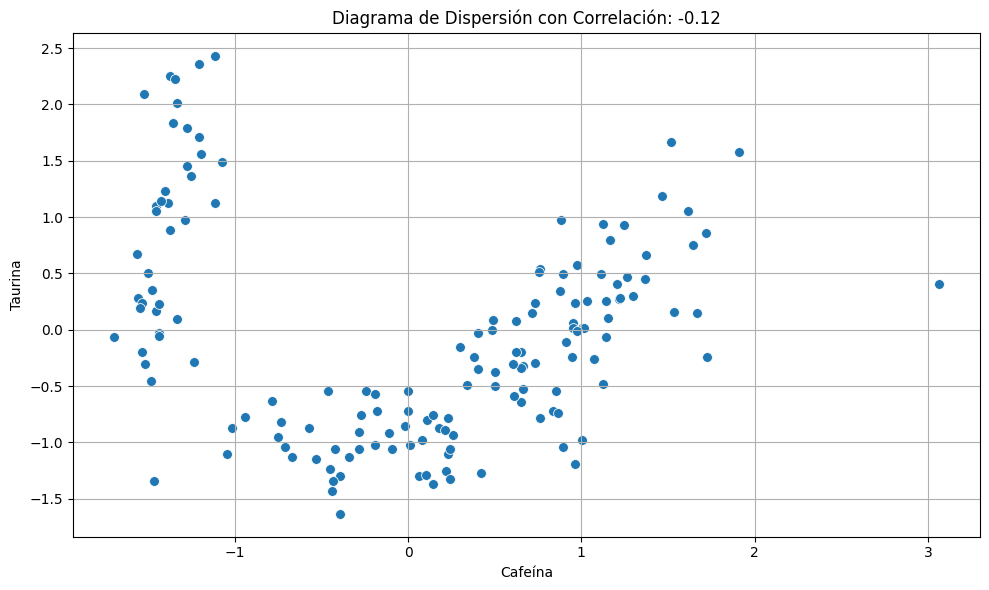

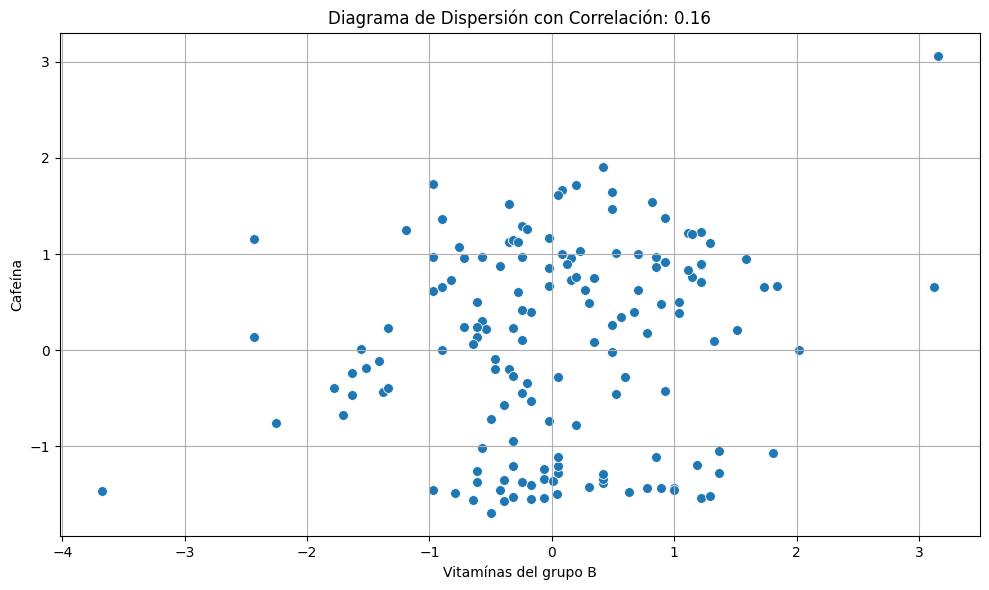

In [ ]:
grafico_dispersion_con_correlacion(df, "Azúcares", "Ácido Cítrico", mostrar_correlacion=True)
grafico_dispersion_con_correlacion(df, "Cafeína", "Taurina", mostrar_correlacion=True)
grafico_dispersion_con_correlacion(df, "Vitamínas del grupo B", "Cafeína", mostrar_correlacion=True)


**Decisión de features**: aunque "Cafeína" es la que más separación aporta ella sola, "Vitamínas del grupo B" tiene poca correlación con el resto (no es redundante) y no queremos perder información antes de ver qué hace el propio algoritmo con todo el conjunto. Como el dataset es pequeño (153 filas × 5 columnas), no hay ninguna penalización computacional relevante por usar las 5 features, así que **nos quedamos con todas las variables** para el modelado y dejamos que sea el propio clustering el que decida. Si al final los resultados no fueran claros, siempre podríamos volver aquí y quedarnos solo con Cafeína/Ácido Cítrico/Taurina.

### 3. Tratamiento de features

Como ya vimos en el describe(), los datos ya están estandarizados (probablemente con un `StandardScaler` antes de entregárnoslos), no hay nulos ni duplicados, y todas las columnas son numéricas. Por tanto, no necesitamos ningún tratamiento adicional: podemos pasar directamente el array de las 5 columnas a los algoritmos de clustering.

In [ ]:
X = df.values
X.shape


(153, 5)

### 4. Selección de modelo e hiperparámetros — Modelo 1: DBSCAN

DBSCAN tiene dos hiperparámetros: `eps` y `min_samples`. Para elegir un `eps` razonable usamos la técnica del **gráfico de k-distancias**: para cada punto calculamos la distancia a su k-ésimo vecino más cercano (con k = min_samples), las ordenamos de menor a mayor, y buscamos el "codo" de la curva — ese codo es un buen candidato para `eps`.

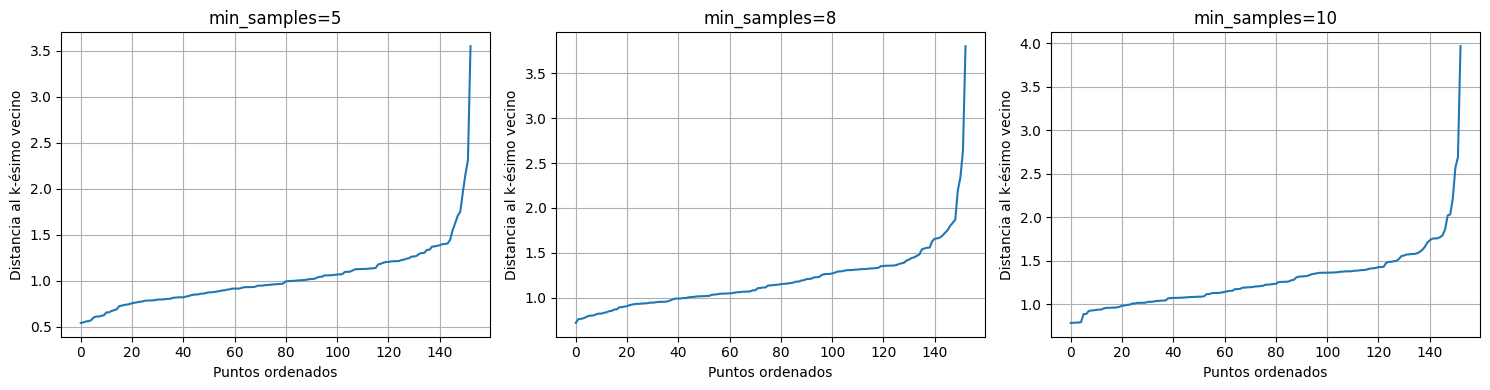

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, min_samples in zip(axes, [5, 8, 10]):
    nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
    dist, _ = nn.kneighbors(X)
    k_dist = np.sort(dist[:, -1])
    ax.plot(k_dist)
    ax.set_title(f"min_samples={min_samples}")
    ax.set_xlabel("Puntos ordenados")
    ax.set_ylabel("Distancia al k-ésimo vecino")
    ax.grid()
plt.tight_layout()
plt.show()


El codo no es súper agudo (es un dataset con clusters bastante juntos), pero se intuye una subida más pronunciada a partir de una distancia de entre 1.3 y 1.6 aproximadamente. Como referencia también tenemos la **nota orientativa de los químicos: entre 3 y 5 segmentos**, así que en vez de quedarnos solo con la lectura visual del codo, hacemos una pequeña búsqueda en rejilla de `eps` y `min_samples`, y nos quedamos con las combinaciones que produzcan entre 3 y 5 clusters (sin contar el ruido), fijándonos en el % de puntos etiquetados como ruido (-1) y en el score de silueta.

In [ ]:
resultados = []
for eps in np.arange(0.6, 2.01, 0.1):
    for min_samples in range(4, 11):
        db_tmp = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels = db_tmp.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        if 3 <= n_clusters <= 5:
            mask = labels != -1
            if mask.sum() > 1 and len(set(labels[mask])) > 1:
                sil = silhouette_score(X[mask], labels[mask])
            else:
                sil = np.nan
            resultados.append({
                "eps": round(eps, 2),
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "%_noise": round(100 * n_noise / len(X), 1),
                "silhouette": round(sil, 3) if sil == sil else None,
            })

resultados_df = pd.DataFrame(resultados).sort_values(["n_clusters", "%_noise"])
resultados_df.head(15)


,eps,min_samples,n_clusters,n_noise,%_noise,silhouette
16,1.1,6,3,14,9.2,0.427
21,1.2,9,3,14,9.2,0.428
22,1.2,10,3,22,14.4,0.453
17,1.1,7,3,25,16.3,0.453
11,1.0,5,3,28,18.3,0.455
18,1.1,8,3,28,18.3,0.461
19,1.1,9,3,37,24.2,0.481
20,1.1,10,3,41,26.8,0.484
13,1.0,7,3,51,33.3,0.501
14,1.0,8,3,61,39.9,0.521


Buscamos un equilibrio entre: pocos puntos marcados como ruido, buen score de silueta, y clusters con un tamaño razonable (no clusters de 2-3 puntos). La combinación **`eps=1.1`, `min_samples=6`** nos da 3 clusters bien poblados (54, 48 y 37 instancias) con solo un 9% de ruido (14 de 153 puntos) y un score de silueta de 0.43, que es de las mejores combinaciones de toda la rejilla. Nos quedamos con ella.

In [ ]:
dbscan_model = DBSCAN(eps=1.1, min_samples=6).fit(X)

from collections import Counter
print("Tamaño de cada cluster (-1 = ruido):", Counter(dbscan_model.labels_))
print("Score de silueta (sin contar el ruido):",
      silhouette_score(X[dbscan_model.labels_ != -1], dbscan_model.labels_[dbscan_model.labels_ != -1]))


Tamaño de cada cluster (-1 = ruido): Counter({np.int64(0): 54, np.int64(1): 48, np.int64(2): 37, np.int64(-1): 14})
Score de silueta (sin contar el ruido): 0.4271458409444442


### 5. Selección de modelo e hiperparámetros — Modelo 2: Clustering Jerárquico

El enunciado ya nos da una pista bastante clara de cuál debería ser el segundo modelo: nos piden **"establecer algún tipo de relación entre las segmentaciones (qué segmentos se parecen más entre sí)"**. Eso es exactamente lo que nos regala el **clustering jerárquico aglomerativo**: al construir el dendrograma no solo obtenemos los clusters, sino también toda la jerarquía de qué grupos se fusionan antes (es decir, cuáles son más parecidos) y a qué "distancia". Ningún otro algoritmo que hayamos visto nos da esto de forma tan directa.

Empezamos trazando el dendrograma con las 5 features, usando enlace `ward` y distancia `euclidean` (la combinación estándar, funciona bien en espacios de pocas dimensiones como el nuestro: 5 features y 153 observaciones).

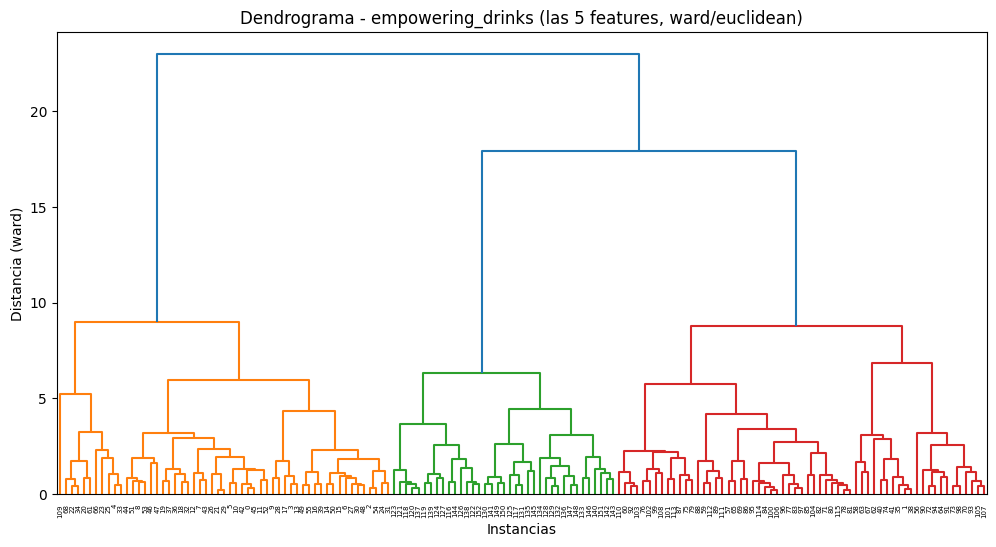

In [ ]:
plt.figure(figsize=(12, 6))
clusters_link = shc.linkage(X, method="ward", metric="euclidean")
shc.dendrogram(clusters_link)
plt.title("Dendrograma - empowering_drinks (las 5 features, ward/euclidean)")
plt.xlabel("Instancias")
plt.ylabel("Distancia (ward)")
plt.show()


El dendrograma se lee solo: hay **tres ramas principales muy claramente separadas** (el primer corte, arriba del todo, separa un grupo de los otros dos; el segundo corte, algo más abajo, separa esos dos restantes). El mayor "hueco" sin líneas verticales está justo ahí arriba, lo que sugiere **k=3** como número natural de clusters. Lo confirmamos comparando el score de silueta para k=3, 4 y 5 (el rango que nos pidieron los químicos):

In [ ]:
for k in [3, 4, 5]:
    ac_tmp = AgglomerativeClustering(n_clusters=k, metric="euclidean", linkage="ward")
    labels_tmp = ac_tmp.fit_predict(X)
    print(f"k={k} -> tamaños={dict(Counter(labels_tmp))}, "
          f"silhouette={silhouette_score(X, labels_tmp):.3f}")


k=3 -> tamaños={np.int64(0): 55, np.int64(1): 61, np.int64(2): 37}, silhouette=0.384
k=4 -> tamaños={np.int64(1): 44, np.int64(0): 61, np.int64(3): 11, np.int64(2): 37}, silhouette=0.337
k=5 -> tamaños={np.int64(1): 44, np.int64(0): 22, np.int64(3): 11, np.int64(4): 39, np.int64(2): 37}, silhouette=0.304


Efectivamente, **k=3 da el mejor score de silueta (0.384)** y además son 3 clusters bien poblados (55, 61 y 37 instancias), mientras que k=4 y k=5 van bajando la silueta y generan algún cluster muy pequeño (11 instancias). Nos quedamos con **k=3**, que además coincide con el número "limpio" de clusters que ya nos había dado el DBSCAN.

In [ ]:
agglo_model = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward").fit(X)
print("Tamaño de cada cluster:", Counter(agglo_model.labels_))
print("Score de silueta:", silhouette_score(X, agglo_model.labels_))


Tamaño de cada cluster: Counter({np.int64(1): 61, np.int64(0): 55, np.int64(2): 37})
Score de silueta: 0.38433386437441397


### 6. Entrenamiento y visualización de resultados

Como tenemos 5 features no podemos pintar directamente un scatter plot. Usamos PCA solo para poder **visualizar** en 2D (ojo: el modelo se ha entrenado con las 5 features originales, el PCA es solo para representar el resultado).

Varianza explicada por las 2 primeras componentes: [0.46945422 0.23248784] -> total: 0.702


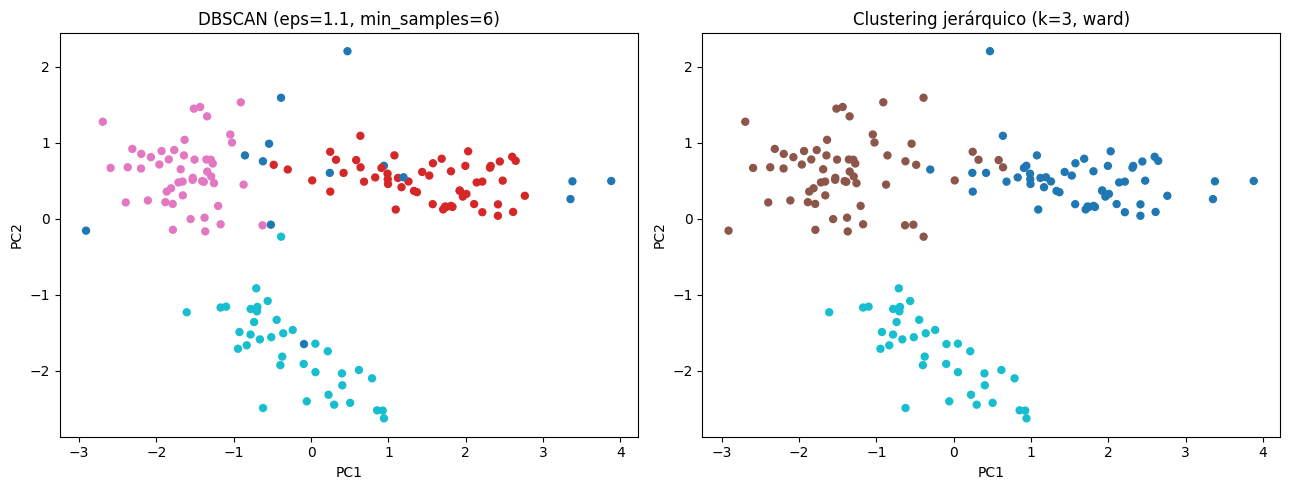

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print("Varianza explicada por las 2 primeras componentes:",
      pca.explained_variance_ratio_, "-> total:", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_model.labels_, cmap="tab10", s=25)
axes[0].set_title("DBSCAN (eps=1.1, min_samples=6)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_model.labels_, cmap="tab10", s=25)
axes[1].set_title("Clustering jerárquico (k=3, ward)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


Las dos figuras se parecen muchísimo: en ambas se aprecian los mismos 3 grupos, y los puntos que DBSCAN marca como ruido (los que quedan "sueltos" entre nubes) son precisamente los que están en la frontera entre dos clusters del modelo jerárquico. Buena señal de que ambos modelos están capturando la misma estructura real de los datos.

### 7. Discusión

Comparamos directamente las etiquetas de ambos modelos con una tabla de contingencia y con el ARI (Adjusted Rand Index), que mide el acuerdo entre dos particiones sin que importe cómo se llame cada cluster (0 = acuerdo aleatorio, 1 = acuerdo perfecto).

In [ ]:
print(pd.crosstab(dbscan_model.labels_, agglo_model.labels_,
                   rownames=["DBSCAN"], colnames=["Jerárquico"]))

mask = dbscan_model.labels_ != -1
ari = adjusted_rand_score(dbscan_model.labels_[mask], agglo_model.labels_[mask])
print("\nARI entre ambos modelos (sin contar el ruido de DBSCAN):", round(ari, 3))


Jerárquico   0   1   2
DBSCAN                
-1           7   6   1
 0          48   6   0
 1           0  48   0
 2           0   1  36

ARI entre ambos modelos (sin contar el ruido de DBSCAN): 0.845


El acuerdo es muy alto (ARI ≈ 0.84): cada cluster de DBSCAN se corresponde casi 1 a 1 con un cluster del modelo jerárquico (48↔48, 46↔48, 36↔37 aprox), con muy poco "mezclado" entre ellos. Los pocos puntos que DBSCAN considera ruido son sobre todo puntos frontera entre los clusters 0 y 1 del jerárquico.

**¿Por qué es una comparación "meramente especulativa"?** Porque en este punto seguimos sin tener ningún target real (ninguna medida de sabor, de efecto "non-stop" ni de preferencia de usuario). Lo único que podemos decir es que **dos algoritmos con lógicas de agrupamiento completamente distintas (uno basado en densidad, el otro en distancias jerárquicas) llegan a una segmentación muy parecida**, lo cual es un indicio razonablemente fuerte de que existe una estructura real en los datos (no es ruido ni una casualidad del algoritmo). Pero seguimos sin poder decir si esos 3 grupos importan de verdad para lo que a los químicos les preocupa (sabor, efecto antifatiga, preferencia del cliente) — eso solo lo sabremos si conseguimos un target real, que es justo lo que pasa en la Parte III.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

**¿Qué modelo usamos?** Ni `DBSCAN` ni `AgglomerativeClustering` tienen un método `.predict()` nativo para clasificar instancias nuevas (son ambos "transductivos": solo devuelven etiquetas para los datos con los que se entrenaron). Como vimos en el notebook de apoyo de DBSCAN, hay que entrenar aparte un clasificador supervisado (por ejemplo KNN) usando las etiquetas de clustering como si fueran el target.

Elegimos reutilizar el **modelo jerárquico** porque es el más sencillo de los dos en este paso: todas sus instancias tienen una etiqueta de cluster "de verdad" (0, 1 o 2), no hay concepto de ruido/anomalía que gestionar aparte. Con DBSCAN tendríamos que decidir además qué hacer con los puntos "core" vs "no core" y con el umbral de distancia para marcar anomalías (como se hace en el notebook de apoyo). Con el jerárquico, simplemente entrenamos un KNN con **todas** las instancias y sus etiquetas, sin pasos extra.

In [ ]:
new_experiments = pd.read_csv("./data/new_experiments.csv", sep="|")
new_experiments


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


In [ ]:
knn_segmentador = KNeighborsClassifier(n_neighbors=5)
knn_segmentador.fit(X, agglo_model.labels_)

X_new = new_experiments.values
pred_new = knn_segmentador.predict(X_new)
proba_new = knn_segmentador.predict_proba(X_new)

resultado_new = new_experiments.copy()
resultado_new["cluster_predicho"] = pred_new
for i, clase in enumerate(knn_segmentador.classes_):
    resultado_new[f"proba_cluster_{clase}"] = proba_new[:, i]

resultado_new


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster_predicho,proba_cluster_0,proba_cluster_1,proba_cluster_2
0,1.481555,0.305159,1.366128,2.239039,0.731870,0,1.0,0.0,0.0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0,1.0,0.0,0.0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1,0.0,1.0,0.0
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1,0.0,1.0,0.0
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2,0.0,0.2,0.8
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2,0.0,0.0,1.0


Los 6 nuevos experimentos quedan repartidos así: los dos primeros van claramente al cluster 0, los dos siguientes al cluster 1 (con total seguridad, probabilidad 1.0), y los dos últimos al cluster 2 — aunque el quinto experimento (índice 4) es el menos claro de todos (80% cluster 2, 20% cluster 1), así que si tuviéramos que priorizar cuál revisar "a mano" antes de fabricarlo, sería ese.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.